In [ ]:
import csv
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import rfft, rfftfreq
import seaborn as sns
from matplotlib.colors import ListedColormap

np.set_printoptions(precision=10, suppress=True)

In [ ]:
# make lists of the data files and sort them by trial number extracted from the filename
load_cell_files = [f for f in os.listdir(os.path.join('..', 'data', 'imu_data')) if f.endswith('_load_cell.csv')]
sorted_load_cell_files = sorted(load_cell_files, key=lambda x: int(''.join(filter(str.isdigit, x))))

accel_0_files = [f for f in os.listdir(os.path.join('..', 'data', 'imu_data')) if f.endswith('_accel0.csv')]
sorted_accel_0_files = sorted(accel_0_files, key=lambda x: int(''.join(filter(str.isdigit, x))))

accel_1_files = [f for f in os.listdir(os.path.join('..', 'data', 'imu_data')) if f.endswith('_accel1.csv')]
sorted_accel_1_files = sorted(accel_1_files, key=lambda x: int(''.join(filter(str.isdigit, x))))

accel_2_files = [f for f in os.listdir(os.path.join('..', 'data', 'imu_data')) if f.endswith('_accel2.csv')]
sorted_accel_2_files = sorted(accel_2_files, key=lambda x: int(''.join(filter(str.isdigit, x))))

In [ ]:
imu_used_by_trial_number = [
    0, 0, 0, 1, 1, 1, 2, 2, 2,
    2, 2, 2, 1, 1, 1, 0, 0, 0,
    0, 0, 0, 1, 1, 1, 2, 2, 2,
    0, 0, 0, 1, 1, 1, 2, 2, 2,
    0, 0, 0, 1, 1, 1, 2, 2, 2,
    0, 0, 0, 1, 1, 1, 2, 2, 2]

def load_imu_csv(file_name):
    """Load one IMU CSV with safe dtypes: int64 timestamps + float32 sensor values."""
    path = os.path.join('..', 'data', 'imu_data', file_name)
    with open(path, 'r') as f:
        reader = csv.reader(f)
        rows = list(reader)

    # Skip header, then split timestamp and sensor columns to avoid float32 overflow.
    body = rows[1:]
    timestamps_ns = np.array([int(r[0]) for r in body], dtype=np.int64)
    sensors = np.array([r[1:] for r in body], dtype=np.float32)

    # Convert to elapsed seconds for numerically stable FFT/sampling calculations.
    time_s = (timestamps_ns - timestamps_ns[0]) * 1e-9
    return timestamps_ns, time_s, sensors

def load_forcedata_csv(file_name):
    """Load one CSV with safe dtypes: int64 timestamps + float32 sensor values.
    The timestamps are adjusted to match the IMU timestamps for alignment."""
    path = os.path.join('..', 'data', 'imu_data', file_name)
    with open(path, 'r') as f:
        reader = csv.reader(f)
        rows = list(reader)

    # Skip header, then split timestamp and sensor columns to avoid float32 overflow.
    body = rows[1:]
    timestamps_ns = np.array([int(r[0]) for r in body], dtype=np.int64)
    sensors = np.array([r[1:] for r in body], dtype=np.float32)

    # Convert to elapsed seconds for numerically stable FFT/sampling calculations.
    time_s = (timestamps_ns - timestamps_ns[0]) * 1e-9
    return timestamps_ns, time_s, sensors

def extract_branch_number(file_name):
    """Extract branch number from names like bush_5_branch_1_trial_2_height_375_accel0.csv."""
    match = re.search(r'_branch_(\d+)(?=_trial_)', file_name)
    if match:
        return int(match.group(1))
    raise ValueError(f"Filename {file_name} does not match expected pattern.")
    

def build_dict_for_trial(trial_num):
    """Build a dictionary containing all imu and load cell data for a given trial number.
    Access via trial_dict['imu0']['time_s'], trial_dict['imu0']['x'], etc."""
    # Load IMU data
    imu_file_0 = sorted_accel_0_files[trial_num]
    imu_timestamps_ns_0, _, imu_sensors_0 = load_imu_csv(imu_file_0)

    imu_file_1 = sorted_accel_1_files[trial_num]
    imu_timestamps_ns_1, _, imu_sensors_1 = load_imu_csv(imu_file_1)

    imu_file_2 = sorted_accel_2_files[trial_num]
    imu_timestamps_ns_2, _, imu_sensors_2 = load_imu_csv(imu_file_2)

    # Load load cell data
    load_cell_file = sorted_load_cell_files[trial_num]
    load_cell_timestamps_ns, _, load_cell_sensors = load_forcedata_csv(load_cell_file)

    ultimate_ns_zero = min(imu_timestamps_ns_0[0], imu_timestamps_ns_1[0], imu_timestamps_ns_2[0], load_cell_timestamps_ns[0])
    imu_time_s_0 = (imu_timestamps_ns_0 - ultimate_ns_zero) * 1e-9
    imu_time_s_1 = (imu_timestamps_ns_1 - ultimate_ns_zero) * 1e-9
    imu_time_s_2 = (imu_timestamps_ns_2 - ultimate_ns_zero) * 1e-9
    load_cell_time_s = (load_cell_timestamps_ns - ultimate_ns_zero) * 1e-9

    last_loadcell_time = load_cell_time_s[-1]
    # get the index of the last imu times that are less than or equal to the last load cell time
    last_imu0_index_before_cutoff = imu_time_s_0[imu_time_s_0 <= last_loadcell_time]
    last_imu1_index_before_cutoff = imu_time_s_1[imu_time_s_1 <= last_loadcell_time]
    last_imu2_index_before_cutoff = imu_time_s_2[imu_time_s_2 <= last_loadcell_time]

    branch_num = extract_branch_number(imu_file_0)

    # Create dictionary
    trial_dict = {
        "imu0": {
            "time_s": imu_time_s_0,
            "x": imu_sensors_0[:, 0],
            "y": imu_sensors_0[:, 1],
            "z": imu_sensors_0[:, 2],
        },
        "imu1": {
            "time_s": imu_time_s_1,
            "x": imu_sensors_1[:, 0],
            "y": imu_sensors_1[:, 1],
            "z": imu_sensors_1[:, 2],
        },
        "imu2": {
            "time_s": imu_time_s_2,
            "x": imu_sensors_2[:, 0],
            "y": imu_sensors_2[:, 1],
            "z": imu_sensors_2[:, 2],
        },
        "load_cell": {
            "time_s": load_cell_time_s,
            "displacement": load_cell_sensors[:, 3],
            "force": load_cell_sensors[:, 2],   
        },
        "branch_num": branch_num,
        "imu_used": imu_used_by_trial_number[trial_num]
    }
    return trial_dict


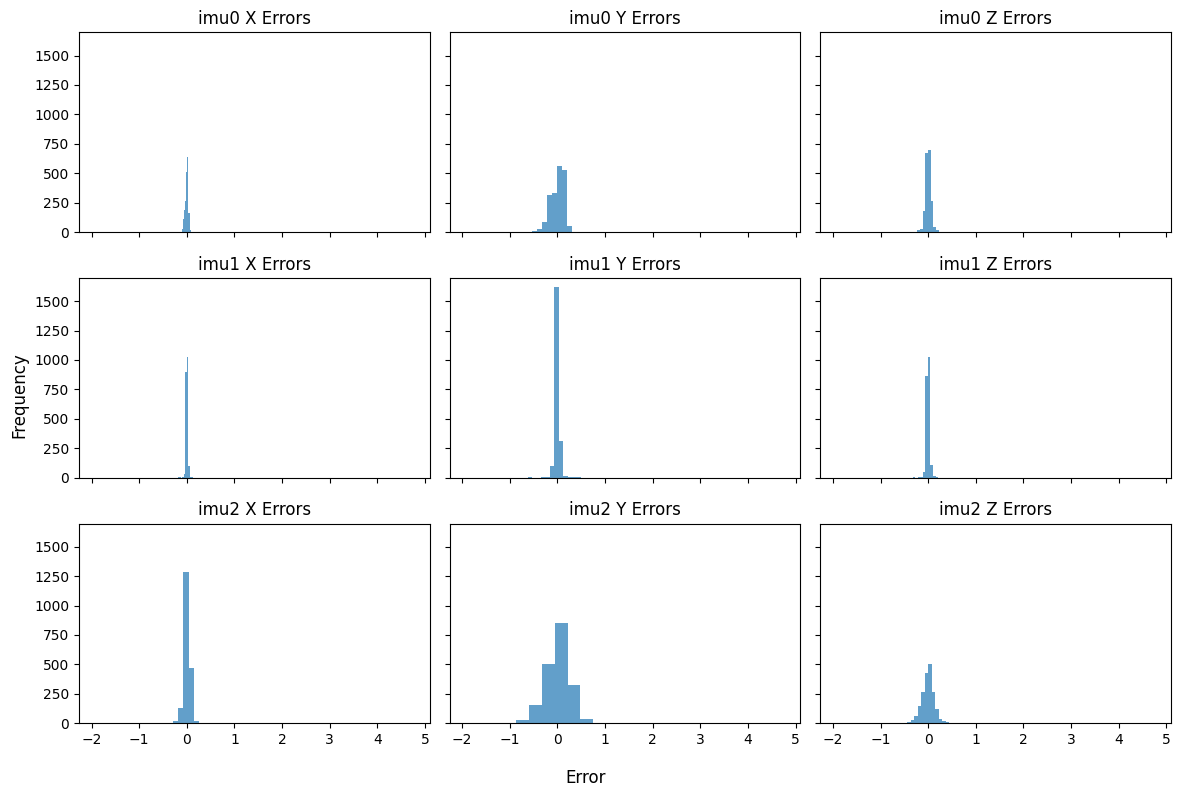

In [ ]:
# load a single trial 
TRIAL_IDX = 52
trial_data = build_dict_for_trial(TRIAL_IDX)

# ------------------------------------------------------------------------------
#               Histograms of acceleration errors
# ------------------------------------------------------------------------------
directions = ['x', 'y', 'z']
imus = ['imu0', 'imu1', 'imu2']

fig, axes = plt.subplots(len(imus), len(directions), figsize=(12, 8), sharex=True, sharey=True)

for j, imu in enumerate(imus):
    for i, direction in enumerate(directions):
        ax = axes[j, i]
        data = trial_data[imu][direction]
        mean_value = np.mean(data)
        errors = data - mean_value
        ax.hist(errors, bins=25, color='tab:blue', alpha=0.7)
        ax.set_title(f'{imu} {direction.upper()} Errors')

fig.supxlabel('Error')
fig.supylabel('Frequency')
fig.tight_layout()
plt.show()

In [ ]:
# From Claude, a smoothed z-score peak detection algorithm for real-time anomaly detection.

def smoothed_zscore_peaks(y, lag=30, threshold=4, influence=0.25):
    """
    Real-time-style peak/anomaly detection using a rolling mean and std,
    matching the algorithm behind many Arduino z-score peak detector libraries.

    Parameters
    ----------
    y : array-like
        Input signal (e.g. your load_cell_reading or accel2_x column).
    lag : int
        Size of the rolling window used to compute mean/std.
        Larger lag = smoother baseline, slower to react to real shifts.
    threshold : float
        Number of standard deviations away from the rolling mean
        before a point is flagged as a peak/anomaly.
    influence : float (0 to 1)
        How much a detected peak affects future rolling mean/std.
        0 = peaks are fully excluded from future stats (most robust,
            assumes signal returns to baseline after a peak).
        1 = peaks are treated like normal data (no robustness benefit).

    Returns
    -------
    signals : np.ndarray of int
        0 = normal, 1 = positive peak, -1 = negative peak, per sample.
    avg_filter, std_filter : np.ndarray
        The rolling mean/std at each point, useful for plotting thresholds.
    """
    y = np.asarray(y, dtype=float)
    n = len(y)
    signals = np.zeros(n, dtype=int)
    filtered_y = y.copy()
    avg_filter = np.zeros(n)
    std_filter = np.zeros(n)

    avg_filter[lag - 1] = np.mean(y[:lag])
    std_filter[lag - 1] = np.std(y[:lag])

    for i in range(lag, n):
        if abs(y[i] - avg_filter[i - 1]) > threshold * std_filter[i - 1]:
            signals[i] = 1 if y[i] > avg_filter[i - 1] else -1
            filtered_y[i] = influence * y[i] + (1 - influence) * filtered_y[i - 1]
        else:
            signals[i] = 0
            filtered_y[i] = y[i]

        avg_filter[i] = np.mean(filtered_y[i - lag + 1 : i + 1])
        std_filter[i] = np.std(filtered_y[i - lag + 1 : i + 1])

    return signals, avg_filter, std_filter

LAG = 40
THRESHOLD = 6
INF = .25

x_peaks, x_avg, x_std = smoothed_zscore_peaks(data[:,1], lag=LAG, threshold=THRESHOLD, influence=INF)
y_peaks, y_avg, y_std = smoothed_zscore_peaks(data[:,2], lag=LAG, threshold=THRESHOLD, influence=INF)   
z_peaks, z_avg, z_std = smoothed_zscore_peaks(data[:,3], lag=LAG, threshold=THRESHOLD, influence=INF)


In [ ]:
# ------------------------------------------------------------------------------
#               Plot the acceleration data on its own
# ------------------------------------------------------------------------------
f, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharex=True, figsize=(12, 8), height_ratios=[1, 1, 1, .75])
ax1.plot(data[:,0], data[:,1], label='Accel X', color='tab:blue')
ax2.plot(data[:,0], data[:,2], label='Accel Y', color='tab:orange')
ax3.plot(data[:,0], data[:,3], label='Accel Z', color='tab:green')
ax4.plot(lc_time_s, lc_sensors[:,2], label='Load Cell', color='tab:red')
# Plot the detected peaks on top of the X acceleration data


# Peak detection plotting
peakx_baseline = np.mean(data[:,1])
ax1.plot(data[:,0], peakx_baseline + 0.75 * x_peaks, label='X Accel Peaks', color='tab:purple', alpha=0.5)
ax1.fill_between(data[LAG:,0], x_avg[LAG:]+THRESHOLD*x_std[LAG:], x_avg[LAG:]-THRESHOLD*x_std[LAG:], color='tab:gray', alpha=0.2, label='X Accel Std Dev')
peaky_baseline = np.mean(data[:,2])
ax2.plot(data[:,0], peaky_baseline + 0.75 * y_peaks, label='Y Accel Peaks', color='tab:purple', alpha=0.5)
ax2.fill_between(data[LAG:,0], y_avg[LAG:]+THRESHOLD*y_std[LAG:], y_avg[LAG:]-THRESHOLD*y_std[LAG:], color='tab:gray', alpha=0.2, label='Y Accel Std Dev')
peakz_baseline = np.mean(data[:,3])
ax3.plot(data[:,0], peakz_baseline + 0.75 * z_peaks, label='Z Accel Peaks', color='tab:purple', alpha=0.5)
ax3.fill_between(data[LAG:,0], z_avg[LAG:]+THRESHOLD*z_std[LAG:], z_avg[LAG:]-THRESHOLD*z_std[LAG:], color='tab:gray', alpha=0.2, label='Z Accel Std Dev')
print(f"Number of Peaks: {np.sum(np.abs(x_peaks))}, Y: {np.sum(np.abs(y_peaks))}, Z: {np.sum(np.abs(z_peaks))}")

# plot labels and titles
ax4.set_xlabel('Time (s)')
ax1.set_ylabel('X Accel (m/s^2)')
ax2.set_ylabel('Y Accel (m/s^2)')
ax3.set_ylabel('Z Accel (m/s^2)')
ax4.set_ylabel('Load Cell (gF)')
plt.suptitle(f'Raw IMU Accelerometer Data: {sorted_imu_files[TRIAL_IDX]}')
ax1.grid()
ax2.grid()
ax3.grid()
ax4.grid()



In [ ]:
trial_nums = list(range(54))

LAG = 40
THRESHOLD = 8
INF = .25
peak_counts = []

for trial_idx in trial_nums:
    timestamps_ns, time_s, sensors = load_imu_csv(sorted_imu_files[trial_idx])
    _, lc_time_s, lc_sensors = load_forcedata_csv(sorted_load_cell_files[trial_idx], timestamps_ns[0])
    data = np.column_stack((time_s, sensors))
    x_peaks, x_avg, x_std = smoothed_zscore_peaks(data[:,1], lag=LAG, threshold=THRESHOLD, influence=INF)
    y_peaks, y_avg, y_std = smoothed_zscore_peaks(data[:,2], lag=LAG, threshold=THRESHOLD, influence=INF)   
    z_peaks, z_avg, z_std = smoothed_zscore_peaks(data[:,3], lag=LAG, threshold=THRESHOLD, influence=INF)
    # print the name of the file and the number of peaks detected in each axis
    peak_counts.append(np.sum(np.abs(x_peaks)) + np.sum(np.abs(y_peaks)) + np.sum(np.abs(z_peaks)))
    # print(f"Trial {trial_idx}: File: {sorted_imu_files[trial_idx]}")
    # print(f"Trial {trial_idx}: Number of Peaks: {np.sum(np.abs(x_peaks))}, Y: {np.sum(np.abs(y_peaks))}, Z: {np.sum(np.abs(z_peaks))}")

In [ ]:
np.resize(peak_counts, (3, 9)).T

In [ ]:
# 3x3 grid 
# trial_nums = [0, 1, 2, 9, 10, 11, 18, 19, 20]
# labels = [['1-1-1: A', '2-1-1: B', '3-1-1: D'], 
#           ['1-1-2: A', '2-1-2: A', '3-1-2: D'], 
#           ['1-1-3: A', '2-1-3: D', '3-1-3: D']]
# color_numbers = np.resize(peak_counts, (3,3)).T

# 9x3 grid (first half)
# labels = [['1-1-1: A', '2-1-1: B', '3-1-1: D'], 
#           ['1-1-2: A', '2-1-2: A', '3-1-2: D'], 
#           ['1-1-3: A', '2-1-3: D', '3-1-3: D'], 
#           ['1-2-1: A (D)', '2-2-1: A', '3-2-1: B'], 
#           ['1-2-2: A', '2-2-2: A', '3-2-2: D'], 
#           ['1-2-3: A', '2-2-3: B', '3-2-3: C'], 
#           ['1-3-1: A', '2-3-1: B', '3-3-1: A'], 
#           ['1-3-2: A', '2-3-2: A', '3-3-2: A'], 
#           ['1-3-3: A', '2-3-3: C', '3-3-3: A']]
# color_numbers = np.resize(peak_counts, (3, 9)).T

labels = [['1-1-1: A', '2-1-1: B (A)', '3-1-1: D (A-)', '4-1-1', '5-1-1: D', '6-1-1: B'], 
          ['1-1-2: A', '2-1-2: A', '3-1-2: D (C)', '4-1-2: B', '5-1-2: D', '6-1-2: A'], 
          ['1-1-3: A*', '2-1-3: D', '3-1-3: D', '4-1-3: D', '5-1-3: D', '6-1-3: A'], 
          ['1-2-1: A (B)', '2-2-1: A', '3-2-1: B', '4-2-1', '5-2-1: B', '6-2-1: B'], 
          ['1-2-2: A (B)', '2-2-2: A (A-)', '3-2-2: D', '4-2-2', '5-2-2: B', '6-2-2: B'], 
          ['1-2-3: A (B)', '2-2-3: B', '3-2-3: C', '4-2-3', '5-2-3: D', '6-2-3: A'], 
          ['1-3-1: A', '2-3-1: B (A-)', '3-3-1: A', '4-3-1: A', '5-3-1', '6-3-1: B'], 
          ['1-3-2: A', '2-3-2: A', '3-3-2: A', '4-3-2: C', '5-3-2', '6-3-2: D'], 
          ['1-3-3: A', '2-3-3: C (A*)', '3-3-3: A', '4-3-3: A', '5-3-3', '6-3-3: B']]
color_numbers = np.resize(peak_counts, (6, 9)).T

cmap = sns.color_palette("coolwarm", as_cmap=True)
sns.heatmap(color_numbers, cmap=cmap, annot=labels, fmt='s', cbar=False)
plt.show()

In [ ]:
# ------------------------------------------------------------------------------
#               FFT (currently useless)
# ------------------------------------------------------------------------------
N = len(data) # number of samples
# get the sampling frequency from the first column of the data
# take the average difference between the first column values to get the sampling frequency
dts = np.diff(data[:,0])
mean_dts = np.mean(dts)
stdev_dts = np.std(dts)

# well, we're going to do this anyway

sampling_freq = 1 / mean_dts
print("Sampling frequency: %.10f Hz" % sampling_freq)

f = rfftfreq(N, mean_dts) # frequencies
ampX, ampY, ampZ = abs(rfft(data[:,1]) / N), abs(rfft(data[:,2]) / N), abs(rfft(data[:,3]) / N)  # Magnitude spectrum
# plot f vs ampX, ampY, ampZ on the same plot with a legend
plt.figure(figsize=(12, 6))
plt.plot(f, ampX, label='Accel X')
# plt.plot(f, ampY, label='Accel Y')
# plt.plot(f, ampZ, label='Accel Z')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.title('FFT of IMU Accelerometer Data')
plt.legend()
plt.grid()
plt.show()

